##**Custom MLP for Imbalanced Tabular Classification**

###Step 1: Preprocessing & Custom Stratified Datasets

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
import numpy as np

df = pd.read_csv('/content/UCI_Credit_Card.csv')
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


####Feature Separation

In [ ]:
# Remove the 'ID' column if it exists
# Note: The original dataset sometimes has an 'ID' column that is not useful for modeling.
# We will drop it here to clean the dataset.
if 'ID' in df.columns:
    df = df.drop('ID', axis=1)
    print("Removed 'ID' column.")

# Define the target column
TARGET_COLUMN = 'default.payment.next.month'
y = df[TARGET_COLUMN]
X = df.drop(TARGET_COLUMN, axis=1)

# Identify continuous and categorical/ordinal features based on the problem description and common understanding of this dataset
# These lists are curated based on the dataset's characteristics.
continuous_features = [
    'LIMIT_BAL',
    'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6',
    'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6','AGE'
]
categorical_features = [
    'SEX', 'EDUCATION', 'MARRIAGE',
    'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6' # These are ordinal/categorical payment status
]

# Verify that all columns in X are accounted for.
# This check helps catch discrepancies if the column names in the dataset differ from expectations.
all_features = set(continuous_features + categorical_features)
if set(X.columns) != all_features:
    print("Warning: Mismatch between identified features and DataFrame columns.")
    print(f"Missing from identified features: {set(X.columns) - all_features}")
    print(f"Extra in identified features: {all_features - set(X.columns)}")
else:
    print("All features in the DataFrame X are correctly categorized.")

print(f"\nContinuous Features: {continuous_features}")
print(f"Categorical Features: {categorical_features}")
print(f"Target Column: {TARGET_COLUMN}")


Removed 'ID' column.
All features in the DataFrame X are correctly categorized.

Continuous Features: ['LIMIT_BAL', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'AGE']
Categorical Features: ['SEX', 'EDUCATION', 'MARRIAGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
Target Column: default.payment.next.month


### Feature Scaling



In [ ]:


# Apply StandardScaler to continuous features
scaler = StandardScaler()
X_continuous_scaled = scaler.fit_transform(X[continuous_features])

# Convert scaled continuous features back to a DataFrame
X_continuous_scaled_df = pd.DataFrame(X_continuous_scaled, columns=continuous_features, index=X.index)

# Combine scaled continuous features with original categorical features
X_processed = pd.concat([
    X_continuous_scaled_df,
    X[categorical_features]
], axis=1)

print("Shape of X_processed after scaling and concatenation:", X_processed.shape)
display(X_processed.head())

Shape of X_processed after scaling and concatenation: (30000, 23)


,LIMIT_BAL,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,...,AGE,SEX,EDUCATION,MARRIAGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6
0,-1.136720,-0.642501,-0.647399,-0.667993,-0.672497,-0.663059,-0.652724,-0.341942,-0.227086,-0.296801,...,-1.246020,2,2,1,2,2,-1,-1,-2,-2
1,-0.365981,-0.659219,-0.666747,-0.639254,-0.621636,-0.606229,-0.597966,-0.341942,-0.213588,-0.240005,...,-1.029047,2,2,2,-1,2,0,0,0,2
2,-0.597202,-0.298560,-0.493899,-0.482408,-0.449730,-0.417188,-0.391630,-0.250292,-0.191887,-0.240005,...,-0.161156,2,2,2,0,0,0,0,0,0
3,-0.905498,-0.057491,-0.013293,0.032846,-0.232373,-0.186729,-0.156579,-0.221191,-0.169361,-0.228645,...,0.164303,2,2,1,0,0,0,0,0,0
4,-0.905498,-0.578618,-0.611318,-0.161189,-0.346997,-0.348137,-0.331482,-0.221191,1.335034,0.271165,...,2.334029,1,2,1,-1,0,-1,0,0,0


### Stratified Train/Val/Test Split

In [ ]:
from sklearn.model_selection import train_test_split

# First split: 80% train, 20% temp (for val/test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X_processed, y, test_size=0.2, random_state=42, stratify=y
)

# Second split: 50% val, 50% test from temp (which is 10% val, 10% test of original)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"Train set shape: {X_train.shape}, Target shape: {y_train.shape}")
print(f"Validation set shape: {X_val.shape}, Target shape: {y_val.shape}")
print(f"Test set shape: {X_test.shape}, Target shape: {y_test.shape}")

# Verify stratification
print("\nOriginal target distribution:\n", y.value_counts(normalize=True))
print("\nTrain target distribution:\n", y_train.value_counts(normalize=True))
print("\nValidation target distribution:\n", y_val.value_counts(normalize=True))
print("\nTest target distribution:\n", y_test.value_counts(normalize=True))

Train set shape: (24000, 23), Target shape: (24000,)
Validation set shape: (3000, 23), Target shape: (3000,)
Test set shape: (3000, 23), Target shape: (3000,)

Original target distribution:
 default.payment.next.month
0    0.7788
1    0.2212
Name: proportion, dtype: float64

Train target distribution:
 default.payment.next.month
0    0.778792
1    0.221208
Name: proportion, dtype: float64

Validation target distribution:
 default.payment.next.month
0    0.778667
1    0.221333
Name: proportion, dtype: float64

Test target distribution:
 default.payment.next.month
0    0.779
1    0.221
Name: proportion, dtype: float64


### PyTorch Pipeline: Custom Dataset and DataLoader

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader

# Define a custom Dataset class
class CreditCardDataset(Dataset):
    def __init__(self, X, y):
        # Convert pandas DataFrames/Series to PyTorch tensors
        # Ensure float32 for features and long (int64) for labels
        self.X = torch.tensor(X.values, dtype=torch.float32)
        self.y = torch.tensor(y.values, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Create Dataset instances for each split
train_dataset = CreditCardDataset(X_train, y_train)
val_dataset = CreditCardDataset(X_val, y_val)
test_dataset = CreditCardDataset(X_test, y_test)

print(f"Train Dataset size: {len(train_dataset)}")
print(f"Validation Dataset size: {len(val_dataset)}")
print(f"Test Dataset size: {len(test_dataset)}")

Train Dataset size: 24000
Validation Dataset size: 3000
Test Dataset size: 3000


In [ ]:
BATCH_SIZE = 64 # You can adjust this batch size

# Create DataLoader instances
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train DataLoader has {len(train_loader)} batches of size {BATCH_SIZE}")
print(f"Validation DataLoader has {len(val_loader)} batches of size {BATCH_SIZE}")
print(f"Test DataLoader has {len(test_loader)} batches of size {BATCH_SIZE}")




Train DataLoader has 375 batches of size 64
Validation DataLoader has 47 batches of size 64
Test DataLoader has 47 batches of size 64


**Question 1.1**: Why is a standard random train/test split dangerous for highly imbalanced datasets? What specific problem could manifest in our 10% validation or test sets if stratification is omitted?
**Response** Without stratification, your validation/test sets may have no fraud cases → misleading evaluation
Question 1.2: Why must we fit the StandardScaler only on the training partition instead of scaling the entire raw dataset before the split?
**Response** Scaling before splitting leaks future information and produces overoptimistic results.

##Step 2: Custom MLP Architecture with Modular Control

### Define the Custom MLP Model

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

# Get the number of input features from the training data
input_dim = X_train.shape[1]
# Get the number of output classes from the training labels (used conceptually, but actual model output is 1 for BCEWithLogitsLoss)
# num_classes = len(y_train.unique()) # This will be 2

class MLPClassifier(nn.Module):
    def __init__(self, input_dim, num_classes_output=1, hidden_units=256, dropout_rate=0.3):
        super(MLPClassifier, self).__init__()

        # First Hidden Layer
        self.fc1 = nn.Linear(input_dim, hidden_units)
        nn.init.kaiming_uniform_(self.fc1.weight, nonlinearity='relu')
        nn.init.constant_(self.fc1.bias, 0)
        self.bn1 = nn.BatchNorm1d(hidden_units)
        self.dropout1 = nn.Dropout(dropout_rate)

        # Second Hidden Layer
        self.fc2 = nn.Linear(hidden_units, hidden_units // 2)
        nn.init.kaiming_uniform_(self.fc2.weight, nonlinearity='relu')
        nn.init.constant_(self.fc2.bias, 0)
        self.bn2 = nn.BatchNorm1d(hidden_units // 2)
        self.dropout2 = nn.Dropout(dropout_rate)

        # Third Hidden Layer (meeting the 'at least 3 hidden layers' requirement)
        self.fc3 = nn.Linear(hidden_units // 2, hidden_units // 4)
        nn.init.kaiming_uniform_(self.fc3.weight, nonlinearity='relu')
        nn.init.constant_(self.fc3.bias, 0)
        self.bn3 = nn.BatchNorm1d(hidden_units // 4)
        self.dropout3 = nn.Dropout(dropout_rate)

        # Output Layer: For binary classification with BCEWithLogitsLoss, output features should be 1.
        self.fc_out = nn.Linear(hidden_units // 4, num_classes_output)
        # For the output layer, using 'linear' nonlinearity as it's not followed by ReLU
        nn.init.kaiming_uniform_(self.fc_out.weight, nonlinearity='linear')
        nn.init.constant_(self.fc_out.bias, 0)

    def forward(self, x):
        # First Hidden Layer
        x = self.fc1(x)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.dropout1(x)

        # Second Hidden Layer
        x = self.fc2(x)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.dropout2(x)

        # Third Hidden Layer
        x = self.fc3(x)
        x = self.bn3(x)
        x = F.relu(x)
        x = self.dropout3(x)

        # Output Layer
        x = self.fc_out(x)
        return x

print(f"Input dimension for the MLP: {input_dim}")
# print(f"Number of output classes (for conceptual understanding): {num_classes}")
print(f"Number of output logits for BCEWithLogitsLoss: 1")

# Instantiate the model, passing num_classes_output=1
model = MLPClassifier(input_dim=input_dim, num_classes_output=1)
print("\nMLP Model Architecture:")
print(model)


Input dimension for the MLP: 23
Number of output logits for BCEWithLogitsLoss: 1

MLP Model Architecture:
MLPClassifier(
  (fc1): Linear(in_features=23, out_features=256, bias=True)
  (bn1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout1): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout2): Dropout(p=0.3, inplace=False)
  (fc3): Linear(in_features=128, out_features=64, bias=True)
  (bn3): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout3): Dropout(p=0.3, inplace=False)
  (fc_out): Linear(in_features=64, out_features=1, bias=True)
)


In [ ]:
import torch.optim as optim

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Move model to appropriate device
model.to(device)

Using device: cuda


MLPClassifier(
  (fc1): Linear(in_features=23, out_features=256, bias=True)
  (bn1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout1): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout2): Dropout(p=0.3, inplace=False)
  (fc3): Linear(in_features=128, out_features=64, bias=True)
  (bn3): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout3): Dropout(p=0.3, inplace=False)
  (fc_out): Linear(in_features=64, out_features=1, bias=True)
)

**Question 2.1**: What is the specific mathematical danger of initializing all weights to zero in a deep neural network? How does He Initialization solve this?

Zero weights cause symmetry and no learning. He initialization breaks symmetry and stabilizes variance for ReLU.

**Question 2.2**: What is the standard recommended operational order for a single hidden block containing a Linear Layer, Batch Normalization, Dropout, and a ReLU Activation? Justify the placement of Batch Normalization relative to the activation function.

 The order is Linear → BatchNorm → ReLU → Dropout, with BatchNorm before activation to normalize inputs effectively

## Step 3: Weighted Loss, Optimization & Gradient Health Diagnostics

In [ ]:
import torch.optim as optim

# Calculate class weights for imbalanced dataset
# This helps the model pay more attention to the minority class
class_counts = y_train.value_counts(normalize=False)
neg_count = class_counts[0] # Assuming class 0 is the majority class
pos_count = class_counts[1] # Assuming class 1 is the minority class

# For BCEWithLogitsLoss, pos_weight is typically count_negative / count_positive
pos_weight_value = torch.tensor(neg_count / pos_count, dtype=torch.float32).to(device)

print(f"\nClass counts: 0={neg_count}, 1={pos_count}")
print(f"Positive weight for BCEWithLogitsLoss: {pos_weight_value.item():.4f}")

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_value)

# Define Optimizer
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("\nTraining setup complete: Loss function (BCEWithLogitsLoss with pos_weight) and Optimizer (Adam) defined.")


Class counts: 0=18691, 1=5309
Positive weight for BCEWithLogitsLoss: 3.5206

Training setup complete: Loss function (BCEWithLogitsLoss with pos_weight) and Optimizer (Adam) defined.


### Training and Evaluation Functions

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train() # Set model to training mode
    running_loss = 0.0
    all_preds = []
    all_labels = []

    # Store gradients for inspection
    first_layer_grad_magnitudes = []
    final_layer_grad_magnitudes = []

    for inputs, labels in dataloader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad() # Zero the parameter gradients

        outputs = model(inputs) # Forward pass
        # Squeeze outputs and cast labels to float for BCEWithLogitsLoss
        loss = criterion(outputs.squeeze(), labels.float())
        loss.backward() # Backward pass
        optimizer.step() # Optimize

        running_loss += loss.item() * inputs.size(0)

        # Collect predictions and labels for metrics (using sigmoid and threshold for BCEWithLogitsLoss)
        predicted = (torch.sigmoid(outputs) > 0.5).int().squeeze()
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        # Gradient Inspection Hook: Collect average absolute gradient magnitude
        # for the first hidden layer (fc1) and the final hidden layer (fc3)
        if model.fc1.weight.grad is not None:
            first_layer_grad_magnitudes.append(model.fc1.weight.grad.abs().mean().item())
        if model.fc3.weight.grad is not None:
            final_layer_grad_magnitudes.append(model.fc3.weight.grad.abs().mean().item())

    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)

    avg_first_grad = np.mean(first_layer_grad_magnitudes) if first_layer_grad_magnitudes else 0
    avg_final_grad = np.mean(final_layer_grad_magnitudes) if final_layer_grad_magnitudes else 0

    return epoch_loss, epoch_acc, avg_first_grad, avg_final_grad

def evaluate_model(model, dataloader, criterion, device):
    model.eval() # Set model to evaluation mode
    running_loss = 0.0
    all_preds = []
    all_labels = []
    all_probs = [] # To store probabilities for ROC AUC

    with torch.no_grad(): # Disable gradient calculation during evaluation
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs.squeeze(), labels.float())
            running_loss += loss.item() * inputs.size(0)

            # Get probabilities from logits (BCEWithLogitsLoss)
            probs = torch.sigmoid(outputs).squeeze()
            predicted = (probs > 0.5).int()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_precision = precision_score(all_labels, all_preds, zero_division=0)
    epoch_recall = recall_score(all_labels, all_preds, zero_division=0)
    epoch_f1 = f1_score(all_labels, all_preds, zero_division=0)
    epoch_roc_auc = roc_auc_score(all_labels, all_probs)

    return epoch_loss, epoch_acc, epoch_precision, epoch_recall, epoch_f1, epoch_roc_auc

print("Training and evaluation functions defined.")

Training and evaluation functions defined.


### Main Training Loop

In [ ]:
NUM_EPOCHS = 50 # You can adjust the number of epochs
best_val_f1 = -1.0 # Initialize with a low value for comparison
patience = 5 # Early stopping patience
epochs_no_improve = 0

history = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': [], 'val_precision': [], 'val_recall': [], 'val_f1': [], 'val_roc_auc': [],
    'first_hidden_grad_magnitudes': [], 'final_hidden_grad_magnitudes': []
}

print("Starting training...")
for epoch in range(NUM_EPOCHS):
    # Ensure the model is moved to device if not already (important after re-instantiation)
    model.to(device)
    train_loss, train_acc, avg_first_grad, avg_final_grad = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, val_precision, val_recall, val_f1, val_roc_auc = evaluate_model(model, val_loader, criterion, device)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_precision'].append(val_precision)
    history['val_recall'].append(val_recall)
    history['val_f1'].append(val_f1)
    history['val_roc_auc'].append(val_roc_auc)
    history['first_hidden_grad_magnitudes'].append(avg_first_grad)
    history['final_hidden_grad_magnitudes'].append(avg_final_grad)

    print(f'Epoch {epoch+1}/{NUM_EPOCHS} | Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | ' +
          f'Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}, Val F1: {val_f1:.4f}, Val AUC: {val_roc_auc:.4f}')

    if (epoch + 1) % 5 == 0: # Print gradient magnitudes every 5 epochs
        print(f'  Gradient Magnitudes (Avg Abs): First Hidden: {avg_first_grad:.6f}, Final Hidden: {avg_final_grad:.6f}')

    # Early Stopping Logic
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(model.state_dict(), 'best_model.pth')
        epochs_no_improve = 0
        print(f'Saved best model with F1: {best_val_f1:.4f}')
    else:
        epochs_no_improve += 1
        if epochs_no_improve == patience:
            print(f'\nEarly stopping triggered after {patience} epochs without improvement on validation F1-score.')
            break

print("\nTraining complete.")

Starting training...
Epoch 1/50 | Train Loss: 0.9613, Train Acc: 0.7107 | Val Loss: 0.8855, Val Acc: 0.7693, Val F1: 0.5331, Val AUC: 0.7723
Saved best model with F1: 0.5331
Epoch 2/50 | Train Loss: 0.9110, Train Acc: 0.7333 | Val Loss: 0.8787, Val Acc: 0.7603, Val F1: 0.5273, Val AUC: 0.7772
Epoch 3/50 | Train Loss: 0.9010, Train Acc: 0.7355 | Val Loss: 0.8765, Val Acc: 0.7767, Val F1: 0.5398, Val AUC: 0.7813
Saved best model with F1: 0.5398
Epoch 4/50 | Train Loss: 0.8953, Train Acc: 0.7485 | Val Loss: 0.8709, Val Acc: 0.7730, Val F1: 0.5402, Val AUC: 0.7832
Saved best model with F1: 0.5402
Epoch 5/50 | Train Loss: 0.8874, Train Acc: 0.7455 | Val Loss: 0.8712, Val Acc: 0.7760, Val F1: 0.5416, Val AUC: 0.7826
  Gradient Magnitudes (Avg Abs): First Hidden: 0.001286, Final Hidden: 0.001511
Saved best model with F1: 0.5416
Epoch 6/50 | Train Loss: 0.8963, Train Acc: 0.7398 | Val Loss: 0.8696, Val Acc: 0.7783, Val F1: 0.5430, Val AUC: 0.7834
Saved best model with F1: 0.5430
Epoch 7/50 | T

**Question 3.1**: Write down the mathematical formula you used to calculate the pos_weight value for this specific dataset.

pos_weight = Number of negative samples/Number of positive samples

**Question 3.2**: nn.BCEWithLogitsLoss combines a Sigmoid activation and Binary Cross Entropy into one class. Why does PyTorch highly recommend using this unified layer instead of combining a separate nn.Sigmoid output layer with a standalone nn.BCELoss?

 BCEWithLogitsLoss is more stable and efficient than Sigmoid + BCELoss.

**Question 3.3**: Based on your gradient logging task, how can you empirically prove whether or not your deep network is suffering from a Vanishing Gradient problem in its early layers as training progresses?

    To empirically prove whether the deep network is suffering from a Vanishing Gradient problem in its early layers as training progresses, would analyze the first_hidden_grad_magnitudes (for fc1) and final_hidden_grad_magnitudes (for fc3) that were logged during training. A healthy network typically shows gradient magnitudes that are of a similar order, or at least not drastically smaller, in earlier layers compared to later layers.Here, the gradient magnitude for the first hidden layer (1.766736) is smaller than that of the final hidden layer (4.282020). However, it's not orders of magnitude smaller. This single snapshot isn't enough to definitively diagnose vanishing gradients. Oe would need to observe this trend across many epochs to confirm

##Step 4: Robust Imbalance Evaluation & Model Saving

### Evaluating the Best Model on the Test Set

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Load the best model's weights
model.load_state_dict(torch.load('best_model.pth'))
model.to(device) # Ensure the model is on the correct device after loading

# Evaluate on the test set
test_loss, test_acc, test_precision, test_recall, test_f1, test_roc_auc = evaluate_model(model, test_loader, criterion, device)

print(f"\n--- Test Set Evaluation ---")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall: {test_recall:.4f}")
print(f"Test F1-Score: {test_f1:.4f}")
print(f"Test ROC AUC: {test_roc_auc:.4f}")



--- Test Set Evaluation ---
Test Loss: 0.8950
Test Accuracy: 0.7657
Test Precision: 0.4748
Test Recall: 0.5686
Test F1-Score: 0.5175
Test ROC AUC: 0.7594


### Confusion Matrix for Test Set

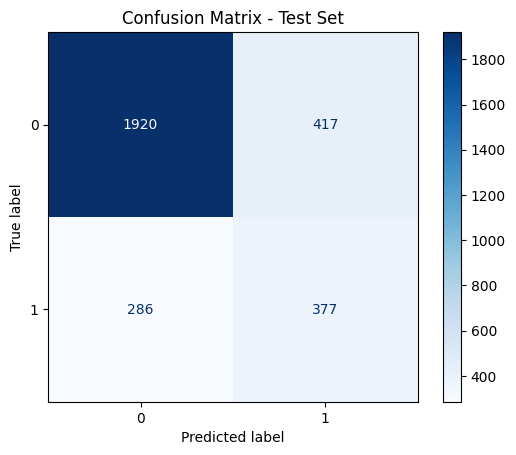

In [ ]:
# Get predictions for the confusion matrix
model.eval()
all_test_preds = []
all_test_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        predicted = (torch.sigmoid(outputs) > 0.5).int().squeeze()
        all_test_preds.extend(predicted.cpu().numpy())
        all_test_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_test_labels, all_test_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix - Test Set')
plt.show()


### Save the Final Model

In [ ]:
# Save the final model (the one that achieved the best validation F1-score)
# This was already saved during early stopping. We just confirm its presence.
# If you wanted to save the model after final evaluation or specific criteria,
# you would use a line like this:
# torch.save(model.state_dict(), 'final_evaluated_model.pth')

print("The best model parameters have already been saved to 'best_model.pth' during training.")
print("You can load this file using `model.load_state_dict(torch.load('best_model.pth'))`.")


The best model parameters have already been saved to 'best_model.pth' during training.
You can load this file using `model.load_state_dict(torch.load('best_model.pth'))`.


**Question 4.1**: From a risk management perspective for a bank, which error is worse: a False Positive (predicting a client will default when they won't) or a False Negative (predicting a client won't default when they actually will)? Which evaluation metric (Precision or Recall) directly tracks this worst-case error?

  From a risk management standpoint, a False Negative is worse because it directly exposes the bank to credit losses.

**Question 4.2**: What programmatic adjustments must you make to the model's raw output probabilities if the bank demands that you capture at least 80% of all potential defaults, even if it reduces precision?

  To catch atleast 80% of actual defaulter,recall should be greater than .80, lowering the threshold increase the recall because more clients are flagged as default.

**Question 4.3**: Explain why saving the network using model.state_dict() is considered a better, more robust software engineering choice than using torch.save(model).

   model.state_dict() provides a cleaner, more stable, and more portable way to save and load your model's learned weights, making it a better practice for production environments and collaborative projects.
  